# New model training and analyzing data


**conversion of raw data to clean data**


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

file_1 = ["/content/api_data_aadhar_demographic_0_500000.csv","/content/api_data_aadhar_demographic_1000000_1500000.csv","/content/api_data_aadhar_demographic_1500000_2000000.csv","/content/api_data_aadhar_demographic_2000000_2071700.csv","/content/api_data_aadhar_demographic_500000_1000000.csv"]
df = pd.concat([pd.read_csv(file)  for file in file_1], ignore_index=True)

df.columns = [ 'date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
df = df.drop('index', axis=1, errors='ignore')
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)    # encoding of date

# Single numeric column
df['date_encoded'] = df['date'].apply(lambda x: x.toordinal())

print("total records :",len(df))
print("Unique raw state:",df['state'].nunique())
df

total records : 2071700
Unique raw state: 65


,date,state,district,pincode,demo_age_5_17,demo_age_17_,date_encoded
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,739311
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,739311
2,2025-03-01,Gujarat,Rajkot,360006,65,765,739311
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,739311
4,2025-03-01,Rajasthan,Udaipur,313801,45,785,739311
...,...,...,...,...,...,...,...
2071695,2025-10-31,Uttar Pradesh,Etah,207250,2,17,739555
2071696,2025-10-31,Uttar Pradesh,Etah,207401,1,27,739555
2071697,2025-10-31,Uttar Pradesh,Etawah,206003,3,10,739555
2071698,2025-10-31,Uttar Pradesh,Etawah,206125,1,25,739555


**cleaning and organizing**

In [ ]:
df['state_clean'] = df['state'].astype(str).str.strip().str.lower()
# df['state_clean']


# mapping
state_mapping = {
    'andaman and nicobar islands': 'Andaman and Nicobar Islands',
    'andaman & nicobar islands': 'Andaman and Nicobar Islands',

    'andhra pradesh': 'Andhra Pradesh',

    'arunachal pradesh': 'Arunachal Pradesh',

    'assam': 'Assam',

    'bihar': 'Bihar',

    'chandigarh': 'Chandigarh',

    'chhattisgarh': 'Chhattisgarh',
    'chhatisgarh': 'Chhattisgarh',

    'dadra and nagar haveli and daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra and nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra & nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman & diu': 'Dadra and Nagar Haveli and Daman and Diu',

    'delhi': 'Delhi',

    'goa': 'Goa',

    'gujarat': 'Gujarat',

    'haryana': 'Haryana',

    'himachal pradesh': 'Himachal Pradesh',

    'jammu and kashmir': 'Jammu and Kashmir',
    'jammu & kashmir': 'Jammu and Kashmir',

    'jharkhand': 'Jharkhand',

    'karnataka': 'Karnataka',

    'kerala': 'Kerala',

    'ladakh': 'Ladakh',

    'lakshadweep': 'Lakshadweep',

    'madhya pradesh': 'Madhya Pradesh',

    'maharashtra': 'Maharashtra',

    'manipur': 'Manipur',

    'meghalaya': 'Meghalaya',

    'mizoram': 'Mizoram',

    'nagaland': 'Nagaland',

    'odisha': 'Odisha',
    'orissa': 'Odisha',

    'punjab': 'Punjab',

    'rajasthan': 'Rajasthan',

    'sikkim': 'Sikkim',

    'tamil nadu': 'Tamil Nadu',

    'telangana': 'Telangana',

    'tripura': 'Tripura',

    'uttar pradesh': 'Uttar Pradesh',

    'uttarakhand': 'Uttarakhand',
    'uttaranchal': 'Uttarakhand',

    'west bengal': 'West Bengal',
    'west  bengal': 'West Bengal',
    'westbengal': 'West Bengal',
    'west bangal': 'West Bengal',
    'west bengli': 'West Bengal',

    'puducherry': 'Puducherry',  # Added based on your data

    # Junk / invalid
    'nan': 'Invalid',
    'none': 'Invalid',
    '': 'Invalid',
}

df['state_final'] = df['state_clean'].map(state_mapping).fillna('Invalid')

# === FINAL RESULTS ===
print("\n=== CLEANING COMPLETE ===")
print("Unique states after cleaning:", df['state_final'].nunique())
print("Invalid records:", (df['state_final'] == 'Invalid').sum())

print("\nValue counts per state (sorted alphabetically):")
print(df['state_final'].value_counts().sort_index())

print("\nList of valid standardized states:")
valid_states = sorted([s for s in df['state_final'].unique() if s != 'Invalid'])
print(valid_states)

# Optional: Save the fully cleaned dataset
df.to_csv('cleaned_full_aadhar_demographic.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_full_aadhar_demographic.csv'")

# If you want only valid states
df_valid = df[df['state_final'] != 'Invalid'].copy()
print("\nRecords with valid states:", len(df_valid))


=== CLEANING COMPLETE ===
Unique states after cleaning: 37
Invalid records: 2193

Value counts per state (sorted alphabetically):
state_final
Andaman and Nicobar Islands                   1724
Andhra Pradesh                              207740
Arunachal Pradesh                             4726
Assam                                        62834
Bihar                                        97621
Chandigarh                                    2044
Chhattisgarh                                 35730
Dadra and Nagar Haveli and Daman and Diu      1627
Delhi                                        10510
Goa                                           5921
Gujarat                                      96399
Haryana                                      28554
Himachal Pradesh                             28037
Invalid                                       2193
Jammu and Kashmir                            20601
Jharkhand                                    39653
Karnataka                                

In [ ]:
df["total_enrollment_demographic"] = (
    df["demo_age_5_17"] + df["demo_age_17_"]
)

state_summary = (
    df.groupby("state_final")["total_enrollment_demographic"]
    .sum()
    .reset_index()
    .sort_values(by="total_enrollment_demographic", ascending=False)
)

# ranking Top 10 states

In [ ]:
state_summary = state_summary.reset_index(drop=True)
state_summary["overall_rank"] = range(1,len(state_summary)+1)

# top 10 rank in order
top10 = state_summary.head(10).copy()
top10 = top10.reset_index(drop=True)
top10["overall_rank"] = range(1,len(top10)+1)

print("The top 10 enrollment states :")
print(
    top10[["overall_rank","state_final","total_enrollment_demographic"]]
    .to_string(index=False)
)

The top 10 enrollment states :
 overall_rank    state_final  total_enrollment_demographic
            1  Uttar Pradesh                       8542328
            2    Maharashtra                       5054602
            3          Bihar                       4814350
            4    West Bengal                       3872737
            5 Madhya Pradesh                       2912938
            6      Rajasthan                       2817615
            7 Andhra Pradesh                       2295582
            8     Tamil Nadu                       2212228
            9   Chhattisgarh                       2005438
           10        Gujarat                       1824327


In [ ]:
df_model = df[df['state_final'] != 'Invalid'].copy()  # or use full df if you want

# 1. Label Encoding for modeling
le = LabelEncoder()
df_model['state_encoded'] = le.fit_transform(df_model['state_final'])

# 2. Save the encoder for future use (e.g., decoding predictions)
joblib.dump(le, 'state_label_encoder.pkl')

# 3. Get the mapping dictionaries (useful for interpretation)
encode_map = dict(zip(le.classes_, le.transform(le.classes_)))          # name -> code
decode_map = dict(zip(le.transform(le.classes_), le.classes_))          # code -> name

print("Sample encoded data:")
print(df_model[['state_final', 'state_encoded']].head(10))

print("\nEncoding map (state name → number):")
print(encode_map)

print("\nDecoding map (number → state name):")
print(decode_map)

Sample encoded data:
      state_final  state_encoded
0   Uttar Pradesh             33
1  Andhra Pradesh              1
2         Gujarat             10
3  Andhra Pradesh              1
4       Rajasthan             28
5       Rajasthan             28
6       Karnataka             15
7   Uttar Pradesh             33
8  Andhra Pradesh              1
9     West Bengal             35

Encoding map (state name → number):
{'Andaman and Nicobar Islands': np.int64(0), 'Andhra Pradesh': np.int64(1), 'Arunachal Pradesh': np.int64(2), 'Assam': np.int64(3), 'Bihar': np.int64(4), 'Chandigarh': np.int64(5), 'Chhattisgarh': np.int64(6), 'Dadra and Nagar Haveli and Daman and Diu': np.int64(7), 'Delhi': np.int64(8), 'Goa': np.int64(9), 'Gujarat': np.int64(10), 'Haryana': np.int64(11), 'Himachal Pradesh': np.int64(12), 'Jammu and Kashmir': np.int64(13), 'Jharkhand': np.int64(14), 'Karnataka': np.int64(15), 'Kerala': np.int64(16), 'Ladakh': np.int64(17), 'Lakshadweep': np.int64(18), 'Madhya Pradesh': np

In [ ]:
features = ['state_encoded', 'date_encoded', 'pincode', 'demo_age_5_17','total_enrollment_demographic']  # etc.
X = df_model[features]
X

,state_encoded,date_encoded,pincode,demo_age_5_17,total_enrollment_demographic
0,33,739311,273213,49,578
1,1,739311,517132,22,397
2,10,739311,360006,65,830
3,1,739311,532484,24,338
4,28,739311,313801,45,830
...,...,...,...,...,...
2071695,33,739555,207250,2,19
2071696,33,739555,207401,1,28
2071697,33,739555,206003,3,13
2071698,33,739555,206125,1,26


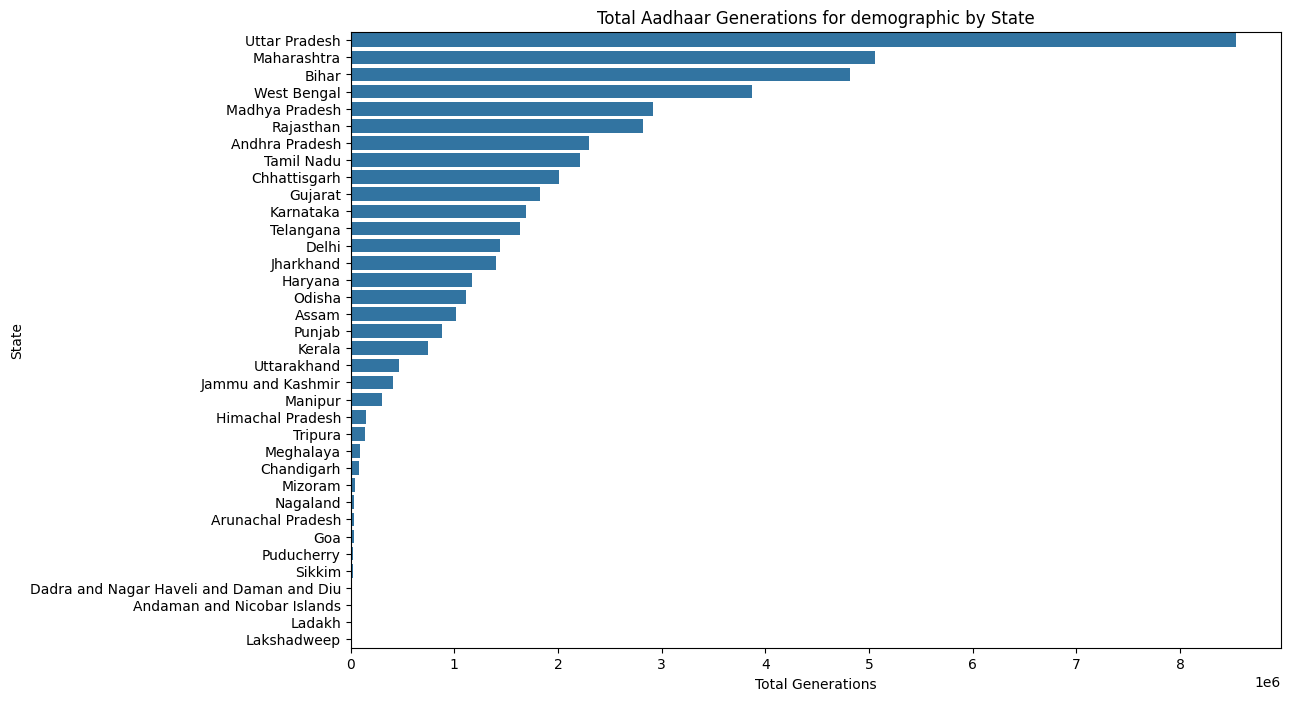

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total Aadhaar generations per state
df_model['total_aadhaar'] = df_model['demo_age_5_17'] + df_model['demo_age_17_']

state_totals = df_model.groupby('state_final')['total_aadhaar'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=state_totals.values, y=state_totals.index)
plt.title('Total Aadhaar Generations for demographic by State')
plt.xlabel('Total Generations')
plt.ylabel('State')
plt.show()

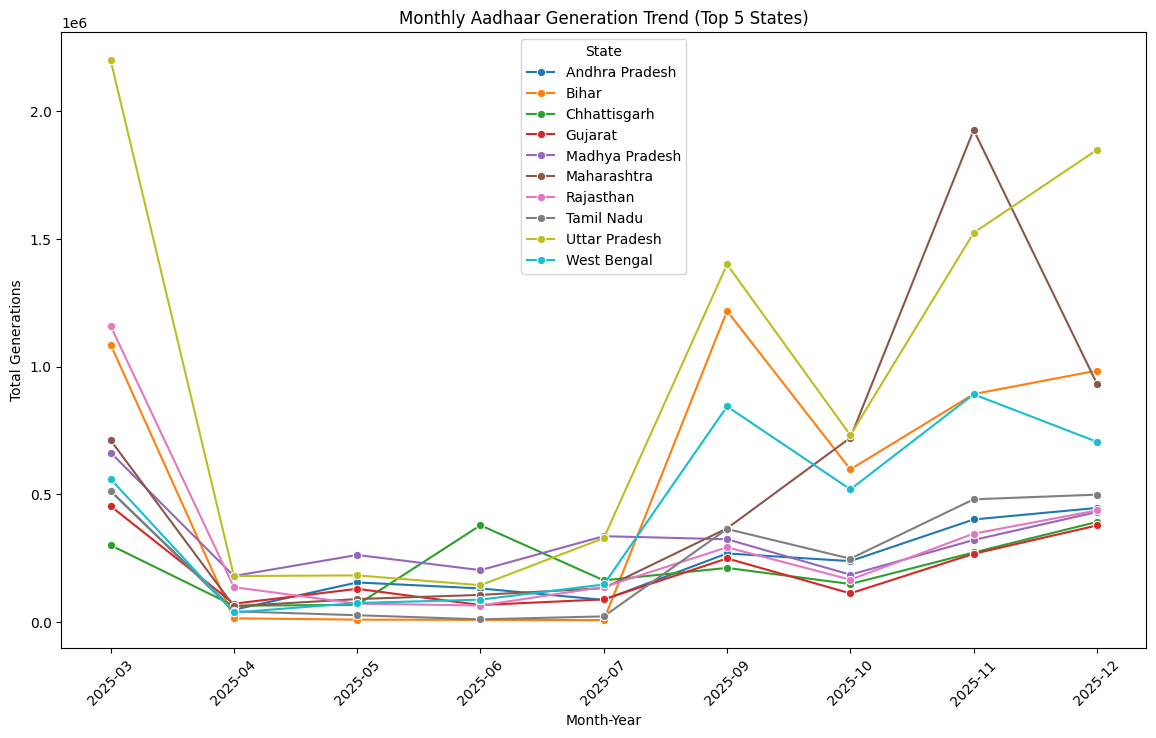

In [ ]:
# Time trend: Monthly total generations per state
df_model['month_year'] = df_model['date'].dt.to_period('M')

monthly_trend = df_model.groupby(['state_final', 'month_year'])['total_aadhaar'].sum().reset_index()
monthly_trend['month_year'] = monthly_trend['month_year'].astype(str)

# Plot for top 5 states
top_states = state_totals.head(10).index
trend_top = monthly_trend[monthly_trend['state_final'].isin(top_states)]

plt.figure(figsize=(14, 8))
sns.lineplot(data=trend_top, x='month_year', y='total_aadhaar', hue='state_final', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Aadhaar Generation Trend (Top 5 States)')
plt.xlabel('Month-Year')
plt.ylabel('Total Generations')
plt.legend(title='State')
plt.show()

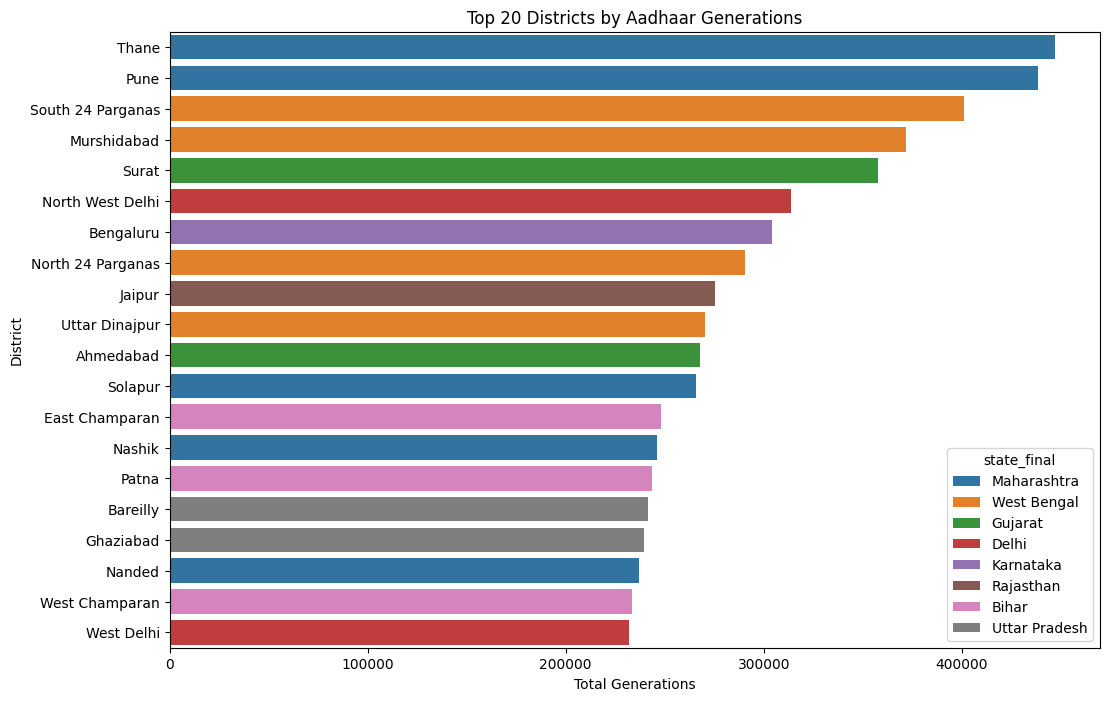

In [ ]:
# Top districts overall
top_districts = df_model.groupby(['state_final', 'district'])['total_aadhaar'].sum().reset_index()
top_districts = top_districts.sort_values('total_aadhaar', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_districts, x='total_aadhaar', y='district', hue='state_final')
plt.title('Top 20 Districts by Aadhaar Generations')
plt.xlabel('Total Generations')
plt.ylabel('District')
plt.show()

In [ ]:
# Make sure you have the cleaned state column and total generations
# Make sure you have the cleaned state column and total generations
df['total_aadhaar'] = df['demo_age_5_17'] + df['demo_age_17_']

# Optional: Exclude Invalid states
df_clean = df[df['state_final'] != 'Invalid'].copy()

# === STATE-LEVEL AGGREGATION ===
state_summary = df_clean.groupby('state_final').agg({
    'total_aadhaar': 'sum',           # Total Aadhaar generated in the state
    'demo_age_5_17': 'sum',           # Total in age 5–17
    'demo_age_17_': 'sum',            # Total in age 17+
    'district': 'nunique',            # How many unique districts
    'pincode': 'nunique',             # How many unique pincodes
    'date': ['min', 'max']             # Date range of data for that state
}).reset_index()

# Flatten the column names after aggregation
state_summary.columns = [
    'state',
    'total_aadhaar_generated',
    'age_5_to_17_generated',
    'age_17_plus_generated',
    'unique_districts',
    'unique_pincodes',
    'earliest_date',
    'latest_date'
]

# Sort by total generations (highest first)
state_summary = state_summary.sort_values('total_aadhaar_generated', ascending=False).reset_index(drop=True)

# Display results
print(f"Number of states: {len(state_summary)}")
print(f"Grand total Aadhaar generated (all states): {state_summary['total_aadhaar_generated'].sum():,}")

state_summary

Number of states: 36
Grand total Aadhaar generated (all states): 49,287,715


,state,total_aadhaar_generated,age_5_to_17_generated,age_17_plus_generated,unique_districts,unique_pincodes,earliest_date,latest_date
0,Uttar Pradesh,8542328,790308,7752020,90,1760,2025-03-01,2025-12-29
1,Maharashtra,5054602,273322,4781280,53,1609,2025-03-01,2025-12-29
2,Bihar,4814350,380023,4434327,47,921,2025-03-01,2025-12-29
3,West Bengal,3872737,242561,3630176,59,1364,2025-03-01,2025-12-29
4,Madhya Pradesh,2912938,407098,2505840,60,796,2025-03-01,2025-12-29
5,Rajasthan,2817615,257224,2560391,46,989,2025-03-01,2025-12-29
6,Andhra Pradesh,2295582,321148,1974434,47,1846,2025-03-01,2025-12-29
7,Tamil Nadu,2212228,315638,1896590,45,2089,2025-03-01,2025-12-29
8,Chhattisgarh,2005438,165207,1840231,39,268,2025-03-01,2025-12-29
9,Gujarat,1824327,208474,1615853,39,1030,2025-03-01,2025-12-29


In [ ]:

state_summary['child_percent'] = (state_summary['age_5_to_17_generated'] / state_summary['total_aadhaar_generated'] * 100).round(2)
state_summary['adult_percent'] = (state_summary['age_17_plus_generated'] / state_summary['total_aadhaar_generated'] * 100).round(2)
state_summary['child_to_adult_ratio'] = (state_summary['age_5_to_17_generated'] / state_summary['age_17_plus_generated']).round(3)



# state

In [ ]:
state_summary[[
    'state',
    'total_aadhaar_generated',
    'age_5_to_17_generated',
    'age_17_plus_generated',
    'child_percent',
    'adult_percent',
    'child_to_adult_ratio',
    'unique_districts',
    'unique_pincodes',
    'earliest_date',
    'latest_date'
]]

,state,total_aadhaar_generated,age_5_to_17_generated,age_17_plus_generated,child_percent,adult_percent,child_to_adult_ratio,unique_districts,unique_pincodes,earliest_date,latest_date
0,Uttar Pradesh,8542328,790308,7752020,9.25,90.75,0.102,90,1760,2025-03-01,2025-12-29
1,Maharashtra,5054602,273322,4781280,5.41,94.59,0.057,53,1609,2025-03-01,2025-12-29
2,Bihar,4814350,380023,4434327,7.89,92.11,0.086,47,921,2025-03-01,2025-12-29
3,West Bengal,3872737,242561,3630176,6.26,93.74,0.067,59,1364,2025-03-01,2025-12-29
4,Madhya Pradesh,2912938,407098,2505840,13.98,86.02,0.162,60,796,2025-03-01,2025-12-29
5,Rajasthan,2817615,257224,2560391,9.13,90.87,0.100,46,989,2025-03-01,2025-12-29
6,Andhra Pradesh,2295582,321148,1974434,13.99,86.01,0.163,47,1846,2025-03-01,2025-12-29
7,Tamil Nadu,2212228,315638,1896590,14.27,85.73,0.166,45,2089,2025-03-01,2025-12-29
8,Chhattisgarh,2005438,165207,1840231,8.24,91.76,0.090,39,268,2025-03-01,2025-12-29
9,Gujarat,1824327,208474,1615853,11.43,88.57,0.129,39,1030,2025-03-01,2025-12-29


In [ ]:
# Top 5 States with HIGHEST Child Percentage (possible school enrollment drives)
print("Top 5 States - Highest Child % (5-17 years) - Possible School Drives")
top_child_percent = state_summary.sort_values('age_5_to_17_generated', ascending=False).head(5)

print(top_child_percent[['state', 'child_percent', 'total_aadhaar_generated', 'age_5_to_17_generated', 'age_17_plus_generated']])

Top 5 States - Highest Child % (5-17 years) - Possible School Drives
            state  child_percent  total_aadhaar_generated  \
0   Uttar Pradesh           9.25                  8542328   
4  Madhya Pradesh          13.98                  2912938   
2           Bihar           7.89                  4814350   
6  Andhra Pradesh          13.99                  2295582   
7      Tamil Nadu          14.27                  2212228   

   age_5_to_17_generated  age_17_plus_generated  
0                 790308                7752020  
4                 407098                2505840  
2                 380023                4434327  
6                 321148                1974434  
7                 315638                1896590  


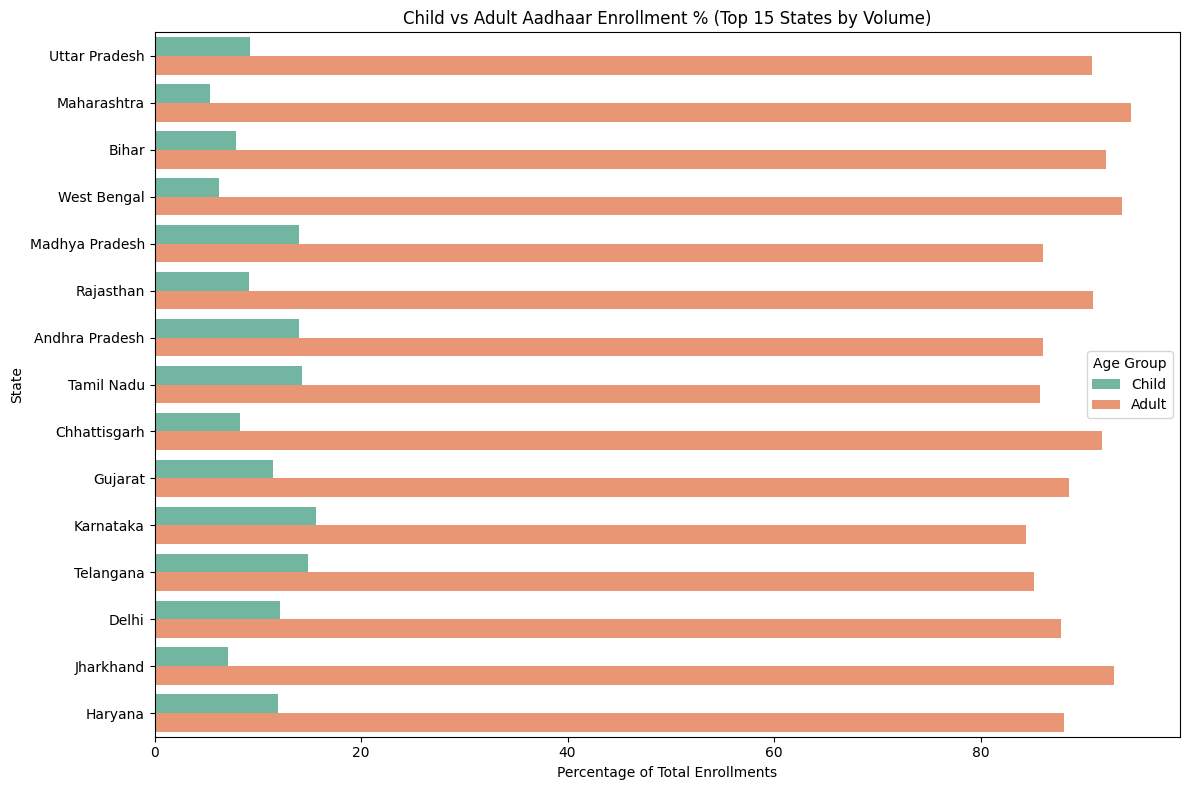

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_15 = state_summary.head(15)

plt.figure(figsize=(12, 8))
melted = top_15.melt(id_vars='state', value_vars=['child_percent', 'adult_percent'],
                     var_name='Age Group', value_name='Percentage')
melted['Age Group'] = melted['Age Group'].str.replace('_percent', '').str.title()

sns.barplot(data=melted, x='Percentage', y='state', hue='Age Group', palette='Set2')
plt.title('Child vs Adult Aadhaar Enrollment % (Top 15 States by Volume)')
plt.xlabel('Percentage of Total Enrollments')
plt.ylabel('State')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

In [ ]:
# States with highest child enrollment percentage
print("Top 5 States - Highest Child % (possible school drives?)")
print(state_summary.sort_values('child_percent', ascending=False).head(5)[['state', 'child_percent', 'total_aadhaar_generated']])

# States with lowest child percentage (more adult-focused?)
# print("\nTop 5 States - Lowest Child %")
# print(state_summary.sort_values('child_percent', ascending=False).tail(5)[['state', 'child_percent', 'total_aadhaar_generated']])

# # States where child-to-adult ratio is highest
# print("\nStates with Highest Child-to-Adult Ratio")
# print(state_summary.sort_values('child_to_adult_ratio', ascending=False).head(8)[['state', 'child_to_adult_ratio', 'child_percent']])

Top 5 States - Highest Child % (possible school drives?)
                                       state  child_percent  \
34                                    Ladakh          23.98   
30                                Puducherry          16.16   
28                         Arunachal Pradesh          15.87   
32  Dadra and Nagar Haveli and Daman and Diu          15.76   
25                                Chandigarh          15.75   

    total_aadhaar_generated  
34                     5735  
30                    25304  
28                    36443  
32                    12204  
25                    83361  


In [ ]:
# Scatter plot
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='demo_age_17_', y='total_aadhaar', data=df)
# plt.title('Bivariate: Total vs Age 17+ Generations')
# plt.show()

# Hexbin for dense data
# plt.figure(figsize=(10, 6))
# df.plot.hexbin(x='demo_age_17_', y='demo_age_5_17', gridsize=30, cmap='Blues')
# plt.title('Bivariate: Density of Age Groups')
# plt.show()

# # Heatmap (aggregated by state and date, example monthly)
# df['month'] = df['date'].dt.to_period('M')
# monthly = df.groupby('month')['total_aadhaar'].sum().reset_index()
# # For true 2-var heatmap, pivot on two categories

KeyError: 'Column not found: total_aadhaar'

In [ ]:
df = df.drop('date', axis=1)
# df = df.drop('state', axis=1)



 ## district encoders
le_district = LabelEncoder()
df['district_label'] = le_district.fit_transform(df['district'])
df

,state,district,pincode,demo_age_5_17,demo_age_17_,date_encoded,state_clean,state_final,total_enrollment_demographic,district_label
0,Uttar Pradesh,Gorakhpur,273213,49,529,739311,uttar pradesh,Uttar Pradesh,578,314
1,Andhra Pradesh,Chittoor,517132,22,375,739311,andhra pradesh,Andhra Pradesh,397,189
2,Gujarat,Rajkot,360006,65,765,739311,gujarat,Gujarat,830,733
3,Andhra Pradesh,Srikakulam,532484,24,314,739311,andhra pradesh,Andhra Pradesh,338,858
4,Rajasthan,Udaipur,313801,45,785,739311,rajasthan,Rajasthan,830,909
...,...,...,...,...,...,...,...,...,...,...
2071695,Uttar Pradesh,Etah,207250,2,17,739555,uttar pradesh,Uttar Pradesh,19,273
2071696,Uttar Pradesh,Etah,207401,1,27,739555,uttar pradesh,Uttar Pradesh,28,273
2071697,Uttar Pradesh,Etawah,206003,3,10,739555,uttar pradesh,Uttar Pradesh,13,274
2071698,Uttar Pradesh,Etawah,206125,1,25,739555,uttar pradesh,Uttar Pradesh,26,274


In [ ]:
df_karnataka = df[df['district']=="Yadgir"].copy()
print(len(df_karnataka))
df_karnataka

1893


,district,pincode,demo_age_5_17,demo_age_17_,date_encoded,district_label
1439,Yadgir,585202,198,615,739372,970
1506,Yadgir,585223,202,500,739403,970
1908,Yadgir,585287,48,218,739311,970
3138,Yadgir,585309,126,360,739311,970
3217,Yadgir,585220,30,135,739311,970
...,...,...,...,...,...,...
2070090,Yadgir,585215,12,25,739555,970
2070091,Yadgir,585216,13,14,739555,970
2070092,Yadgir,585237,3,14,739555,970
2070093,Yadgir,585315,0,7,739555,970


In [ ]:
y = df_karnataka[[ 'demo_age_5_17', 'demo_age_17_']]
y

,demo_age_5_17,demo_age_17_
1439,198,615
1506,202,500
1908,48,218
3138,126,360
3217,30,135
...,...,...
2070090,12,25
2070091,13,14
2070092,3,14
2070093,0,7


In [ ]:
df_karnataka['avg_enrollments'] = df_karnataka[['demo_age_5_17', 'demo_age_17_']].mean(axis=1)

print(df_karnataka[['district', 'pincode', 'demo_age_5_17', 'demo_age_17_', 'avg_enrollments']].head())

     district  pincode  demo_age_5_17  demo_age_17_  avg_enrollments
1439   Yadgir   585202            198           615            406.5
1506   Yadgir   585223            202           500            351.0
1908   Yadgir   585287             48           218            133.0
3138   Yadgir   585309            126           360            243.0
3217   Yadgir   585220             30           135             82.5


In [ ]:
avg_child = df['demo_age_5_17'].mean()
avg_adult = df['demo_age_17_'].mean()

overall_avg = (df['demo_age_5_17'].sum() + df['demo_age_17_'].sum()) / (2 * len(df))

print(f"Average child enrollments: {avg_child:.2f}")
print(f"Average adult enrollments: {avg_adult:.2f}")
print(f"Overall average enrollment: {overall_avg:.2f}")


Average child enrollments: 2.35
Average adult enrollments: 21.45
Overall average enrollment: 11.90


# Demographic Averages by District + Pincode

In [ ]:
grouped_avg = df_karnataka.groupby(['district', 'pincode'])[['demo_age_5_17', 'demo_age_17_']].mean().round(2)

grouped_avg['total_enrollments_avg'] = grouped_avg['demo_age_5_17'] + grouped_avg['demo_age_17_']
grouped_avg['overall_avg'] = grouped_avg[['demo_age_5_17', 'demo_age_17_']].mean(axis=1)
child_percentage = (grouped_avg['demo_age_5_17'] / grouped_avg['overall_avg'] * 100).round(1)

print(grouped_avg.sort_values('total_enrollments_avg', ascending=False).head(20))

                  demo_age_5_17  demo_age_17_  total_enrollments_avg  \
district pincode                                                       
Yadgir   585202           15.57         50.53                  66.10   
         585223            9.48         33.05                  42.53   
         585216            8.54         27.93                  36.47   
         585221            6.02         22.13                  28.15   
         585215            5.99         17.58                  23.57   
         585321            3.68         17.11                  20.79   
         585309            4.14         15.94                  20.08   
         585214            2.76         14.71                  17.47   
         585290            2.78         12.53                  15.31   
         585237            3.23         10.53                  13.76   
         585355            1.64         11.18                  12.82   
         585323            2.02          8.29                  1

In [ ]:
A= df_karnataka.drop(['demo_age_5_17', 'demo_age_17_','district','avg_enrollments'],axis=1)
A

,pincode,date_encoded,district_label
1439,585202,739372,970
1506,585223,739403,970
1908,585287,739311,970
3138,585309,739311,970
3217,585220,739311,970
...,...,...,...
2070090,585215,739555,970
2070091,585216,739555,970
2070092,585237,739555,970
2070093,585315,739555,970


In [ ]:
# x = df_karnataka.drop(['district'],axis=1)
# x

,pincode,demo_age_5_17,demo_age_17_,date_encoded,district_label
263,585201,0,1,739557,52
264,585237,0,1,739557,52
265,585315,0,1,739557,52
621,585202,5,16,739558,52
622,585216,13,20,739558,52
...,...,...,...,...,...
111486,585215,12,25,739555,52
111487,585216,13,14,739555,52
111488,585237,3,14,739555,52
111489,585315,0,7,739555,52


**DATA SPLITING**

In [ ]:
features = [
    'district_label',
    'pincode',
    'demo_age_5_17',     # Child enrollments help predict adult
    'date_encoded',
    'avg_enrollments'

]

x = df_karnataka[features]
y = df_karnataka['demo_age_17_']

x

,district_label,pincode,demo_age_5_17,date_encoded,avg_enrollments
1439,970,585202,198,739372,406.5
1506,970,585223,202,739403,351.0
1908,970,585287,48,739311,133.0
3138,970,585309,126,739311,243.0
3217,970,585220,30,739311,82.5
...,...,...,...,...,...
2070090,970,585215,12,739555,18.5
2070091,970,585216,13,739555,13.5
2070092,970,585237,3,739555,8.5
2070093,970,585315,0,739555,3.5


 **Train-Test Split**


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)


**training with x**

In [ ]:
x_train

,district_label,pincode,demo_age_5_17,date_encoded,avg_enrollments
1770056,970,585214,2,739590,6.5
984155,970,585216,4,739571,3.0
1884516,970,585287,1,739611,3.5
130805,970,585315,0,739545,0.5
786140,970,585215,4,739503,7.0
...,...,...,...,...,...
92050,970,585287,3,739513,5.0
2063973,970,585214,3,739554,4.0
2041249,970,585290,2,739541,13.0
864557,970,585202,4,739543,8.0


**testing with x**

In [ ]:
x_test

,district_label,pincode,demo_age_5_17,date_encoded,avg_enrollments
1010412,970,585223,4,739587,15.5
963264,970,585202,1,739567,10.0
1217743,970,585218,0,739506,1.5
499228,970,585319,1,739513,7.0
1002820,970,585224,0,739574,1.0
...,...,...,...,...,...
467525,970,585214,0,739505,3.5
1832751,970,585315,2,739605,3.0
927646,970,585237,1,739559,2.0
1860358,970,585317,1,739582,0.5


**traning with y**

In [ ]:
y_train

,demo_age_17_
1770056,11
984155,2
1884516,6
130805,1
786140,10
...,...
92050,7
2063973,5
2041249,24
864557,12


**testing with y**

In [ ]:
y_test

,demo_age_17_
1010412,27
963264,19
1217743,3
499228,13
1002820,2
...,...
467525,7
1832751,4
927646,3
1860358,0


# model building

##linear regression

# Training the model

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

### applying the model

In [ ]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

In [ ]:
y_lr_train_pred

array([11.,  2.,  6., ..., 24., 12.,  3.])

In [ ]:
y_lr_test_pred

array([ 2.70000000e+01,  1.90000000e+01,  3.00000000e+00,  1.30000000e+01,
        2.00000000e+00,  1.00000000e+00,  2.00000000e+00,  7.00000000e+00,
        1.00000000e+01,  8.00000000e+00,  2.00000000e+00,  2.70000000e+01,
        1.10000000e+01,  1.00000000e+01, -1.53210777e-14,  1.50000000e+01,
        1.20000000e+01,  2.00000000e+00,  2.00000000e+00,  2.00000000e+00,
        6.00000000e+00,  1.00000000e+00,  4.00000000e+00,  1.00000000e+00,
        1.80000000e+01,  4.00000000e+00,  6.00000000e+00,  9.00000000e+00,
        5.00000000e+00,  6.00000000e+00,  4.00000000e+00,  1.00000000e+01,
        3.00000000e+00,  8.00000000e+00,  1.00000000e+01,  1.00000000e+00,
        5.00000000e+00,  1.40000000e+01,  3.00000000e+00,  1.00000000e+00,
        7.00000000e+00,  1.00000000e+00,  7.00000000e+00,  8.00000000e+00,
        1.30000000e+01,  1.80000000e+01,  4.00000000e+00,  4.00000000e+00,
        5.00000000e+00,  5.00000000e+00,  1.60000000e+01,  4.00000000e+00,
        7.00000000e+00,  

# Evaluate model performance

In [ ]:
y_train

,demo_age_17_
1770056,11
984155,2
1884516,6
130805,1
786140,10
...,...
92050,7
2063973,5
2041249,24
864557,12


In [ ]:
from sklearn.metrics import mean_squared_error ,r2_score

lr_train_mse = mean_squared_error(y_train,y_lr_train_pred)
lr_train_r2 = r2_score(y_train,y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test,y_lr_test_pred)
lr_test_r2 = r2_score(y_test,y_lr_test_pred)

In [ ]:
print('LR MSE(Train):' , lr_train_mse)
print("LR R2 (Train): ",lr_train_r2)
print('LR MSE(Test):' , lr_test_mse)
print("LR R2 (Test): ",lr_test_r2)

LR MSE(Train): 2.414565708607199e-27
LR R2 (Train):  1.0
LR MSE(Test): 1.8416234271933266e-27
LR R2 (Test):  1.0


In [ ]:
lr_result = pd.DataFrame(['Linear Regression',lr_train_mse,lr_train_r2,lr_test_mse,lr_test_r2]).transpose()
lr_result.columns = ['Method','Training MSE','Training R2','Testing MSE','Testing R2']

In [ ]:
lr_result

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,0.0,1.0,0.0,1.0


# Random Forest

**Training the model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=2, random_state=100)

In [ ]:
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

**Evaluate the model**

In [ ]:
from sklearn.metrics import mean_squared_error ,r2_score

rf_train_mse = mean_squared_error(y_train,y_rf_train_pred)
rf_train_r2 = r2_score(y_train,y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test,y_rf_test_pred)
rf_test_r2 = r2_score(y_test,y_rf_test_pred)

In [ ]:
rf_result = pd.DataFrame(['Random Forest',rf_train_mse,rf_train_r2,rf_test_mse,rf_test_r2]).transpose()
rf_result.columns = ['Method','Training MSE','Training R2','Testing MSE','Testing R2']
rf_result

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Random Forest,63.512938,0.975646,51.953252,0.964989


# XGBOOST MODEL


In [ ]:
from xgboost import XGBRegressor
XGB = XGBRegressor(
    max_depth=2,
    random_state=100
)
XGB.fit(x_train, y_train)
print("XGBoost training complete.")

XGBoost training complete!


In [ ]:
y_xgb_train_pred = XGB.predict(x_train)
y_xgb_test_pred = XGB.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error ,r2_score

xgb_train_mse = mean_squared_error(y_train,y_xgb_train_pred)
xgb_train_r2 = r2_score(y_train,y_xgb_train_pred)

xgb_test_mse = mean_squared_error(y_test,y_xgb_test_pred)
xgb_test_r2 = (f'{r2_score(y_test,y_xgb_test_pred):.4f}')

In [ ]:
xgb_result = pd.DataFrame(['XGBoost',xgb_train_mse,xgb_train_r2,xgb_test_mse,xgb_test_r2]).transpose()
xgb_result.columns = ['Method','Training MSE','Training R2','Testing MSE','Testing R2']
xgb_result

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,XGBoost,0.15351,0.999941,0.114483,0.9999


In [ ]:
final_df_model = pd.concat([lr_result,rf_result,xgb_result],axis=0)
final_df_model.columns = ['Methods','Training MSE','Training R2','Testing MSE','Testing R2']
final_df_model
final_df_model.reset_index(drop=True)

,Methods,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,0.0,1.0,0.0,1.0
1,Random Forest,63.512938,0.975646,51.953252,0.964989
2,XGBoost,0.15351,0.999941,0.114483,0.9999


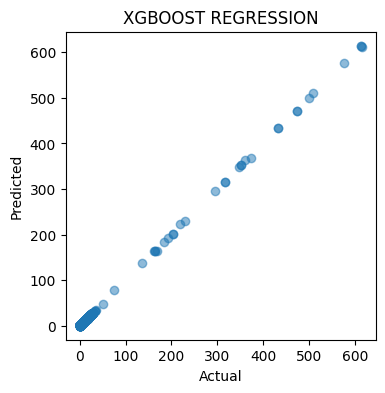

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.scatter(x=y_train, y=y_xgb_train_pred,alpha=0.5)
plt.plot()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBOOST REGRESSION')
plt.show()